1. Dataset Loading

In [26]:
import pandas as pd

from tensorflow.keras.datasets import cifar10

In [27]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

2. Preprocessing


In [28]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0


In [29]:
 x_train_flt = x_train.reshape(x_train.shape[0],-1)

In [30]:
x_test_flt= x_test.reshape(x_test.shape[0],-1)

3. Model Architecture


In [31]:
from tensorflow.keras.utils import to_categorical

In [32]:
y_train_ohe=to_categorical(y_train)
y_test_ohe=to_categorical(y_test)

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout, BatchNormalization

In [34]:
model = Sequential([
    Dense(1024, activation="relu", input_shape=(3072,)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
import tensorflow as tf


4. Training


In [36]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [37]:
history = model.fit(
    x_train_flt,
    y_train_ohe,
    validation_split=0.2,
    epochs=15,
    batch_size=128
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - accuracy: 0.2454 - loss: 2.3786 - val_accuracy: 0.3192 - val_loss: 1.8622
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.3397 - loss: 1.8516 - val_accuracy: 0.3734 - val_loss: 1.7432
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.3802 - loss: 1.7275 - val_accuracy: 0.3198 - val_loss: 1.8686
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.3972 - loss: 1.6892 - val_accuracy: 0.3695 - val_loss: 1.7516
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.4020 - loss: 1.6632 - val_accuracy: 0.4090 - val_loss: 1.6596
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.4062 - loss: 1.6459 - val_accuracy: 0.3809 - val_loss: 1.7085
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 91ms/step - accuracy: 0.4120 - loss: 1.6421 - val_accuracy: 0.4308 - val_loss: 1.5614
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - accuracy: 0.4149 - loss: 1.6383 - 

In [38]:
import matplotlib.pyplot as plt

5. Visualization


In [39]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

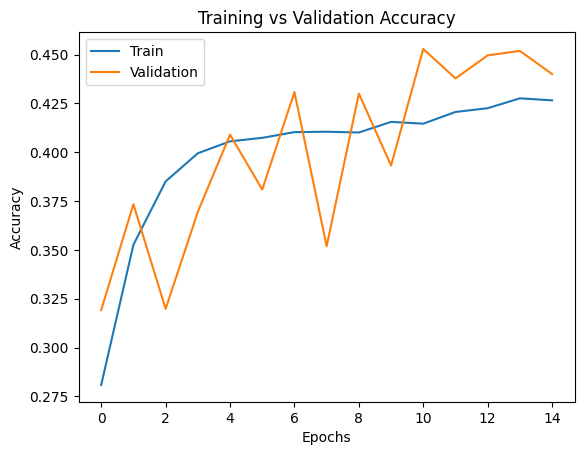

In [40]:
plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

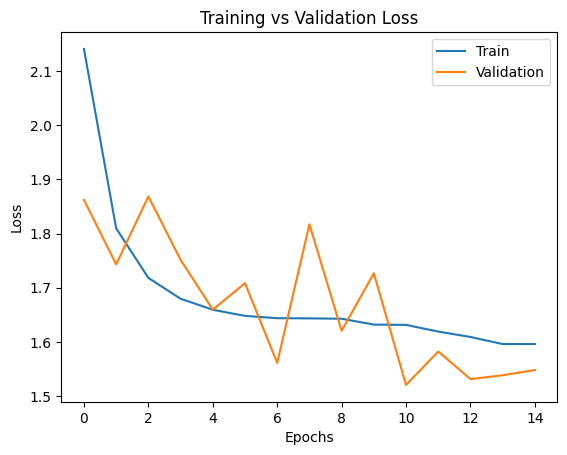

In [41]:
plt.figure()
plt.plot(history.history["loss"]),
plt.plot(history.history["val_loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend(["Train", "Validation"])
plt.show()

6. Evaluation


In [42]:
test_loss,test_acc= model.evaluate(x_test_flt,y_test_ohe)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4494 - loss: 1.5211
Test Accuracy: 0.45339998602867126
Test Loss: 1.522996425628662


In [43]:

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]



In [46]:
import numpy as np
y_pred = model.predict(x_test_flt)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_ohe, axis=1)



313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


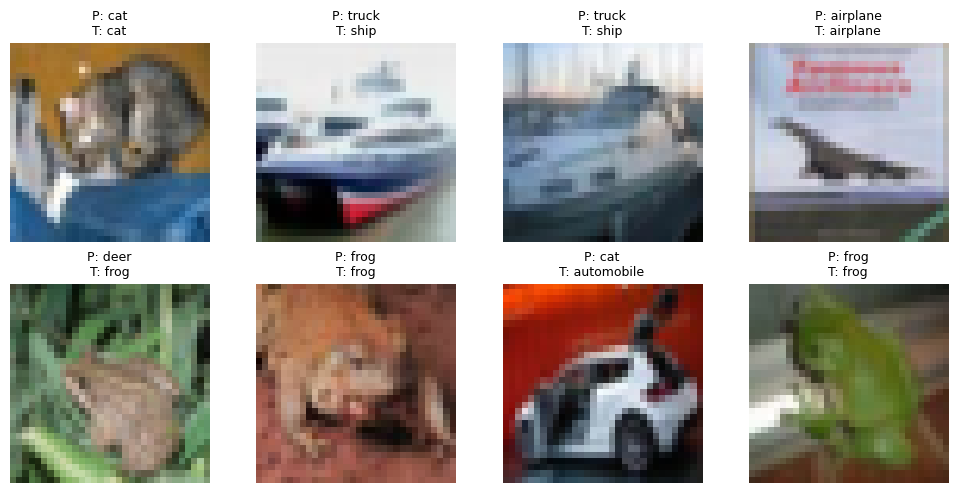

In [47]:
plt.figure(figsize=(10, 5))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_test[i])
    plt.title(
        f"P: {class_names[y_pred_classes[i]]}\n"
        f"T: {class_names[y_true[i]]}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()
